# Loading

In [445]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os

BASEDIR = "../LOGS"

In [446]:
runs = pd.read_csv(os.path.join(BASEDIR, "runs.csv"), on_bad_lines='skip')
search_info = pd.read_csv(os.path.join(BASEDIR, "search_settings.csv"), index_col='id')
index_info = pd.read_csv(os.path.join(BASEDIR, "index_settings.csv"), index_col='id').drop_duplicates()

# Join the two dataframes where runs['settings_id'] is the id of the search settings
df = pd.merge(runs, search_info, left_on='settings_id', right_on='id', how='left', suffixes=('_run', '_settings'))

# Fill nans
for col in df.columns:
    if 'time' in col:
        df[col] = df[col].fillna(0)

print(df.columns)

df

Index(['id', 'settings_id', 'query_id', 'query_length', 'query_channels',
       'result_set_ts_indices', 'result_set_ts_positions',
       'result_set_distances', 'num_leaves_visited', 'num_nodes_visited',
       'num_ts_examined', 'total_time_s', 'first_layer_time_s',
       'tree_traversal_time_s', 'io_time_s', 'ts_examination_time_s',
       'index_file', 'dataset_file', 'ffts_file', 'query_file', 'num_queries',
       'query_type', 'r_range_r', 'knn_k', 'exact', 'normalized',
       'search_method', 'distance_measure', 'early_abandoning'],
      dtype='object')


,id,settings_id,query_id,query_length,query_channels,result_set_ts_indices,result_set_ts_positions,result_set_distances,num_leaves_visited,num_nodes_visited,...,query_file,num_queries,query_type,r_range_r,knn_k,exact,normalized,search_method,distance_measure,early_abandoning
0,0,0,0,256,1;1;1;1;1,47.0,174.0,39.406650,0.0,0.0,...,mts/query_rwalk_n1000_m512_c5.txt,20,knn,NaN,1,1,1,sequential_scan,ed,0.0
1,1,0,1,256,1;1;1;1;1,53.0,136.0,28.336004,0.0,0.0,...,mts/query_rwalk_n1000_m512_c5.txt,20,knn,NaN,1,1,1,sequential_scan,ed,0.0
2,2,0,2,256,1;1;1;1;1,91.0,168.0,36.048121,0.0,0.0,...,mts/query_rwalk_n1000_m512_c5.txt,20,knn,NaN,1,1,1,sequential_scan,ed,0.0
3,3,0,3,256,1;1;1;1;1,266.0,23.0,27.051709,0.0,0.0,...,mts/query_rwalk_n1000_m512_c5.txt,20,knn,NaN,1,1,1,sequential_scan,ed,0.0
4,4,0,4,256,1;1;1;1;1,359.0,42.0,39.936682,0.0,0.0,...,mts/query_rwalk_n1000_m512_c5.txt,20,knn,NaN,1,1,1,sequential_scan,ed,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34229,32674,431,94,1792,1;1;1;1;1,105.0,191.0,3130.461636,0.0,0.0,...,mts/stocks_n2000_m2048_c5/stocks_queries_cq5_1...,100,knn,NaN,1,1,1,sequential_scan,ed,1.0
34230,32675,446,91,1792,1;1;1;1;1,4391.0,62.0,91.999655,0.0,0.0,...,mts/stocks_n5000_m2048_c5/stocks_queries_cq5_1...,100,knn,NaN,1,1,1,sequential_scan,ed,1.0
34231,32676,445,87,1792,1;1;1;1;1,5124.0,126.0,85.407574,0.0,0.0,...,mts/stocks_n6000_m2048_c5/stocks_queries_cq5_1...,100,knn,NaN,1,1,1,sequential_scan,ed,1.0
34232,32677,431,95,1792,1;1;1;1;1,737.0,256.0,7648.563806,0.0,0.0,...,mts/stocks_n2000_m2048_c5/stocks_queries_cq5_1...,100,knn,NaN,1,1,1,sequential_scan,ed,1.0


In [447]:
# Infer necessary columns for main df
ALGOS = ['BRUTE_FORCE', 'MASS', 'MULISSE+MASS', 'MULISSE+BF']

# Algorithm -- dependent on combinations of search method and distance measure
def get_algorithm(row):
    search_method = row.search_method
    distance_measure = row.distance_measure
    ffts_precomputed = not pd.isna(row.ffts_file)
    early_abandon = row.early_abandoning == 1

    if 'scan' in search_method and distance_measure == 'ed' and not ffts_precomputed and early_abandon:
        return 'BRUTE_FORCE'
    elif 'scan' in search_method and distance_measure == 'mass' and ffts_precomputed:
        return 'MASS'
    elif 'isax' in search_method and distance_measure == 'ed' and early_abandon:
        return 'MULISSE+BF'
    elif 'isax' in search_method and distance_measure == 'ed' and not early_abandon:
        return 'MULISSE+BF no EA'
    elif 'isax' in search_method and distance_measure == 'mass' and ffts_precomputed:
        return 'MULISSE+MASS'
    
    else:
        return np.nan
    
import re
def get_regex(string, regex):
    if pd.isna(string):
        return np.nan

    match = re.search(regex, string)
    if match:
        return match.group(1)
    else:
        return np.nan
    
# Get the algorithm from the search method and distance measure
df['algorithm'] = df.apply(get_algorithm, axis=1)
    
# Get the number of channels from the dataset_file after "_c{num_channels}" with regex
df['num_channels'] = df.dataset_file.apply(lambda x: float(get_regex(x, r'_c(\d+)')))

# Get the number of series from the dataset_file after "_n{num_series}" with regex
df['num_series'] = df.dataset_file.apply(lambda x: float(get_regex(x, r'_n(\d+)')))

# Get the length of the series from the dataset_file after "_m{series_length}" with regex
df['series_length'] = df.dataset_file.apply(lambda x: float(get_regex(x, r'_m(\d+)')))

df['l_min'] = df.index_file.apply(lambda x: float(get_regex(x, r'_lmin(\d+)')))
df['l_max'] = df.index_file.apply(lambda x: float(get_regex(x, r'_lmax(\d+)')))
    
df['early_abandoning'] = df.early_abandoning.fillna(0)

df['dataset'] = df.dataset_file.str.extract(r'(\w+).bin')
df['dataset'] = df.dataset.str.split("_").str[0]

df['num_query_channels'] = df.query_channels.str.count('1')

df[['algorithm', 'dataset_file', 'index_file', 'dataset', 'query_channels', 'num_query_channels', 'num_series', 'series_length', 'num_channels', 'l_min', 'l_max']]

,algorithm,dataset_file,index_file,dataset,query_channels,num_query_channels,num_series,series_length,num_channels,l_min,l_max
0,NaN,mts/rwalk_n1000_m512_c5.bin,NaN,rwalk,1;1;1;1;1,5,1000.0,512.0,5.0,NaN,NaN
1,NaN,mts/rwalk_n1000_m512_c5.bin,NaN,rwalk,1;1;1;1;1,5,1000.0,512.0,5.0,NaN,NaN
2,NaN,mts/rwalk_n1000_m512_c5.bin,NaN,rwalk,1;1;1;1;1,5,1000.0,512.0,5.0,NaN,NaN
3,NaN,mts/rwalk_n1000_m512_c5.bin,NaN,rwalk,1;1;1;1;1,5,1000.0,512.0,5.0,NaN,NaN
4,NaN,mts/rwalk_n1000_m512_c5.bin,NaN,rwalk,1;1;1;1;1,5,1000.0,512.0,5.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
34229,BRUTE_FORCE,mts/stocks_n2000_m2048_c5/stocks.bin,NaN,stocks,1;1;1;1;1,5,2000.0,2048.0,5.0,NaN,NaN
34230,BRUTE_FORCE,mts/stocks_n5000_m2048_c5/stocks.bin,NaN,stocks,1;1;1;1;1,5,5000.0,2048.0,5.0,NaN,NaN
34231,BRUTE_FORCE,mts/stocks_n6000_m2048_c5/stocks.bin,NaN,stocks,1;1;1;1;1,5,6000.0,2048.0,5.0,NaN,NaN
34232,BRUTE_FORCE,mts/stocks_n2000_m2048_c5/stocks.bin,NaN,stocks,1;1;1;1;1,5,2000.0,2048.0,5.0,NaN,NaN


In [448]:
index_info

,dataset_file,index_file,ffts_file,l_min,l_max,normalized,index_type,segment_length,pos_per_env,first_layer_num_bits,leaf_capacity,breakpoint_strategy,split_strategy,min_num_bits_on_tie,num_bits_limit,indexing_time_s,fft_calc_time_s
id,,,,,,,,,,,,,,,,,
0,mts/stocks_n1000_m512_c5.bin,mts/stocks_n1000_m512_c5.bin.massindex,mts/stocks_n1000_m512_c5.bin.ffts,512,512,1,isax_envelope,32,1,1,64,equiprobable,entropy_maximizing,1,12,0.914534,1.144305
1,mts/stocks_n1000_m512_c5.bin,mts/stocks_n1000_m512_c5.bin.massindex,mts/stocks_n1000_m512_c5.bin.ffts,512,512,1,isax_envelope,32,1,1,64,equiprobable,entropy_maximizing,1,12,0.896231,0.991689
2,mts/stocks_n1000_m512_c5.bin,mts/stocks_n1000_m512_c5.bin.mulisseindex,mts/stocks_n1000_m512_c5.bin.ffts,512,512,1,isax_envelope,32,1,1,64,equiprobable,entropy_maximizing,1,12,1.048133,0.960669
3,mts/stocks_n1000_m512_c5.bin,mts/stocks_n1000_m512_c5.bin_lmin256_lmax512.m...,mts/stocks_n1000_m512_c5.bin_lmin256_lmax512.ffts,256,512,1,isax_envelope,32,257,1,64,equiprobable,entropy_maximizing,1,12,3.697627,0.761421
4,mts/stocks_n1000_m2048_c5/stocks.bin,mts/stocks_n1000_m2048_c5/stocks.bin.massindex,mts/stocks_n1000_m2048_c5/stocks.bin.ffts,2048,2048,1,isax_envelope,32,1,1,64,equiprobable,entropy_maximizing,1,12,0.223889,1.718517
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
311,mts/stocks_n4000_m2048_c5/stocks.bin,mts/stocks_n4000_m2048_c5/mulisseindex_lmin153...,mts/stocks_n4000_m2048_c5/mulisse-ffts.bin,1536,2048,1,isax_envelope,32,513,1,64,equiprobable,entropy_maximizing,1,12,25.493703,6.935321
311,mts/stocks_n5000_m2048_c5/stocks.bin,mts/stocks_n5000_m2048_c5/mulisseindex_lmin153...,NaN,1536,2048,1,isax_envelope,32,513,1,64,equiprobable,entropy_maximizing,1,12,31.863938,0.000000
311,mts/stocks_n5000_m2048_c5/stocks.bin,mts/stocks_n5000_m2048_c5/mulisseindex_lmin153...,mts/stocks_n5000_m2048_c5/mulisse-ffts.bin,1536,2048,1,isax_envelope,32,513,1,64,equiprobable,entropy_maximizing,1,12,31.840378,8.568315


In [449]:
# Infer the columns from the index settings
def get_algorithm(row):
    if pd.isna(row.index_file) and not pd.isna(row.ffts_file):
        return 'MASS'
    elif not pd.isna(row.index_file) and pd.isna(row.ffts_file):
        return 'MULISSE+BF'
    elif not pd.isna(row.index_file):
        return 'MULISSE+MASS'
    else:
        return np.nan
    
index_info['algorithm'] = index_info.apply(get_algorithm, axis=1)

# Add MASS rows based on the fourier calc time of mulisse mass
mass = index_info[index_info.algorithm == 'MULISSE+MASS']
mass['algorithm'] = 'MASS'
mass['indexing_time_s'] = 0

index_info = pd.concat([index_info, mass])

index_info['indexing_time_s'] += index_info['fft_calc_time_s']

# Get the inferred rows
index_info['l_min'] = index_info.index_file.apply(lambda x: float(get_regex(x, r'_lmin(\d+)')))
index_info['l_max'] = index_info.index_file.apply(lambda x: float(get_regex(x, r'_lmax(\d+)')))
index_info['dataset'] = index_info.index_file.apply(lambda x: x.split("/")[1].split("_")[0])
index_info['num_channels'] = index_info.index_file.apply(lambda x: float(get_regex(x, r'_c(\d+)')))
index_info['num_series'] = index_info.index_file.apply(lambda x: float(get_regex(x, r'_n(\d+)')))
index_info['series_length'] = index_info.index_file.apply(lambda x: float(get_regex(x, r'_m(\d+)')))

index_info[['algorithm', 'index_file', 'ffts_file', 'l_min', 'l_max', 'dataset', 'num_channels', 'num_series', 'series_length']]

/tmp/ipykernel_82076/832093517.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mass['algorithm'] = 'MASS'
/tmp/ipykernel_82076/832093517.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mass['indexing_time_s'] = 0


,algorithm,index_file,ffts_file,l_min,l_max,dataset,num_channels,num_series,series_length
id,,,,,,,,,
0,MULISSE+MASS,mts/stocks_n1000_m512_c5.bin.massindex,mts/stocks_n1000_m512_c5.bin.ffts,NaN,NaN,stocks,5.0,1000.0,512.0
1,MULISSE+MASS,mts/stocks_n1000_m512_c5.bin.massindex,mts/stocks_n1000_m512_c5.bin.ffts,NaN,NaN,stocks,5.0,1000.0,512.0
2,MULISSE+MASS,mts/stocks_n1000_m512_c5.bin.mulisseindex,mts/stocks_n1000_m512_c5.bin.ffts,NaN,NaN,stocks,5.0,1000.0,512.0
3,MULISSE+MASS,mts/stocks_n1000_m512_c5.bin_lmin256_lmax512.m...,mts/stocks_n1000_m512_c5.bin_lmin256_lmax512.ffts,256.0,512.0,stocks,5.0,1000.0,512.0
4,MULISSE+MASS,mts/stocks_n1000_m2048_c5/stocks.bin.massindex,mts/stocks_n1000_m2048_c5/stocks.bin.ffts,NaN,NaN,stocks,5.0,1000.0,2048.0
...,...,...,...,...,...,...,...,...,...
308,MASS,mts/stocks_n2000_m2048_c5/mulisseindex_lmin153...,mts/stocks_n2000_m2048_c5/mulisse-ffts.bin,1536.0,2048.0,stocks,5.0,2000.0,2048.0
307,MASS,mts/stocks_n3000_m2048_c5/mulisseindex_lmin153...,mts/stocks_n3000_m2048_c5/mulisse-ffts.bin,1536.0,2048.0,stocks,5.0,3000.0,2048.0
311,MASS,mts/stocks_n4000_m2048_c5/mulisseindex_lmin153...,mts/stocks_n4000_m2048_c5/mulisse-ffts.bin,1536.0,2048.0,stocks,5.0,4000.0,2048.0


In [450]:
# Plotting parameters
sns.set(style="whitegrid")
colorblind = sns.color_palette("colorblind")
blues = sns.color_palette("Blues", 2)
FONTSIZE = 20

COLORS = {
    'MULISSE+MASS': colorblind[0],
    'MULISSE+BF': blues[0],
    'MASS': colorblind[1],
    'BRUTE_FORCE': colorblind[2],
}

FIGDIR = "/home/jens/tue/3.MultivariateTimeSeries/variable_subsequence_search/multisa25/figures"

In [451]:
def plot(view, outname=None, dataset=None, xlabel=None, ylabel=None, xticklabels=None, legend=False, yscale=False, annot=False):
    fig, ax = plt.subplots(figsize=(6, 4))

    # Match palette to algorithms
    palette = [COLORS[algo] for algo in view.columns]

    # Plotting
    view.plot(kind='bar', ax=ax, color=palette, edgecolor='black', linewidth=2, width=0.8, rot=0)

    # Labels
    ax.set_ylabel(ylabel, fontsize=FONTSIZE)
    ax.set_xlabel(xlabel, fontsize=FONTSIZE)

    # Title
    ax.set_title(dataset, fontsize=FONTSIZE, fontweight='bold')

    # Yscale
    if yscale:
        ax.set_yscale('log')

    # Ticks
    ax.tick_params(axis='both', which='major', labelsize=FONTSIZE)
    if xticklabels:
        ax.set_xticklabels(xticklabels)

    # Legend
    if legend:
        ax.legend(title=None, fontsize=FONTSIZE, frameon=False)
    else:
        ax.get_legend().remove()

    # Annotate
    if annot:
        for i,p in enumerate(ax.patches[::-1]):
            h = p.get_height()
            ax.annotate(f"{p.get_height():.1f}", (p.get_x() + p.get_width() / 2., h), 
                        ha='center', va='center', xytext=(0, 10), textcoords='offset points', 
                        fontsize=FONTSIZE-2, 
                        bbox=dict(boxstyle="round,pad=0.1", facecolor='white', alpha=0.5)
                        )
            
        # Increase the ylim
        ylims = ax.get_ylim()
        ax.set_ylim(ylims[0], ylims[1] * 2)
    

    # Save
    plt.tight_layout()
    plt.savefig(os.path.join(FIGDIR, outname), dpi=300, bbox_inches='tight')

In [462]:
def iqr_mean(series):
    """Calculates the mean of the 25-75 IQR of a pandas Series."""
    q1 = series.quantile(0)
    q3 = series.quantile(0.75)
    return series[(series >= q1) & (series <= q3)].mean()

def zmean(series):
    z = (series - series.mean()) / series.std()
    r = 2
    series = series[(z >= -r) & (z <= r)]
    return series.mean()

def topmedian(series):
    # Remove the top 10% largest values and take the median
    return series[series < series.quantile(0.9)].median()


# EXP 1: Index time over $n$

In [243]:
view = index_info[
    (index_info.algorithm.isin(['MASS', 'MULISSE+BF', 'MULISSE+MASS'])) &
    (index_info.dataset == 'stocks') &
    (index_info.num_channels == 5) &
    (index_info.series_length == 2048) &
    (index_info.num_series > 0) &
    (index_info.num_series % 1000 == 0) &
    True
]

view = view[
    ((~view.algorithm.str.contains("MULISSE")) | ((view.l_min == 1536) & (view.l_max == 2048)))
]

view.groupby(['algorithm', 'num_series']).size().unstack()

num_series,1000.0,2000.0,3000.0,4000.0,5000.0,6000.0,7000.0,8000.0,9000.0,10000.0
algorithm,,,,,,,,,,
MASS,22,10,10,10,34,10,10,10,10,9
MULISSE+BF,5,5,5,5,12,5,5,5,5,5
MULISSE+MASS,11,5,5,5,8,5,5,5,5,4


In [244]:
view.groupby(['algorithm', 'num_series']).indexing_time_s.mean().unstack()

num_series,1000.0,2000.0,3000.0,4000.0,5000.0,6000.0,7000.0,8000.0,9000.0,10000.0
algorithm,,,,,,,,,,
MASS,1.972132,3.479702,5.290015,6.966771,8.782856,10.521271,12.220037,13.831298,15.787243,17.565207
MULISSE+BF,6.446471,12.845246,19.209828,25.462371,31.890116,38.307842,44.696775,51.047216,57.329560,64.327571
MULISSE+MASS,8.480243,16.258661,24.541718,32.481869,40.554776,48.932392,56.622632,64.656995,72.833774,81.191535


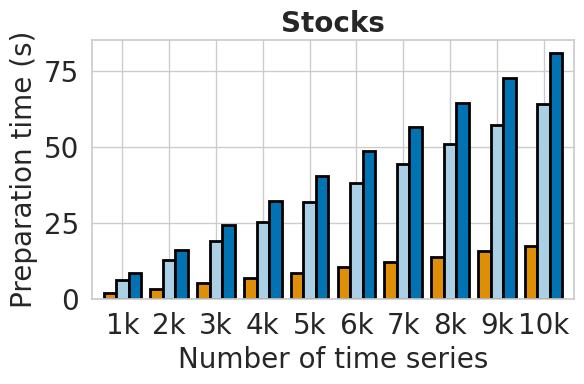

In [245]:
# Plot
plot(view.groupby(['num_series', 'algorithm']).indexing_time_s.mean().unstack(),
        outname='indexing_time_stocks.pdf',
        xlabel='Number of time series',
        ylabel='Preparation time (s)',
        dataset='Stocks',
        xticklabels=[f'{int(x/1000)}k' for x in view.num_series.unique()]
    )

# EXP 2: Query time over n

In [480]:
view = df[
    (df.algorithm.isin(ALGOS)) &
    (df.dataset == 'stocks') &
    (df.num_channels == 5) &
    (df.num_query_channels == 5) &
    (df.series_length == 2048) &
    (df.num_series > 0) &
    (df.num_series % 1000 == 0) &
    (df.query_length == 1792) &
    True
]

view = view[
    ((~view.algorithm.str.contains("MULISSE+BF")) | ((view.l_min == 1536) & (view.l_max == 2048)))
]

view.groupby(['algorithm', 'query_length', 'num_series']).size().unstack()

,num_series,1000.0,2000.0,3000.0,4000.0,5000.0,6000.0,7000.0,8000.0,9000.0,10000.0
algorithm,query_length,,,,,,,,,,
BRUTE_FORCE,1792,320,316,320,319,567,208,120,218,120,219
MASS,1792,240,120,109,82,131,63,58,51,53,49
MULISSE+BF,1792,300,300,300,300,592,200,200,200,200,200
MULISSE+MASS,1792,288,200,198,187,214,161,150,150,152,152


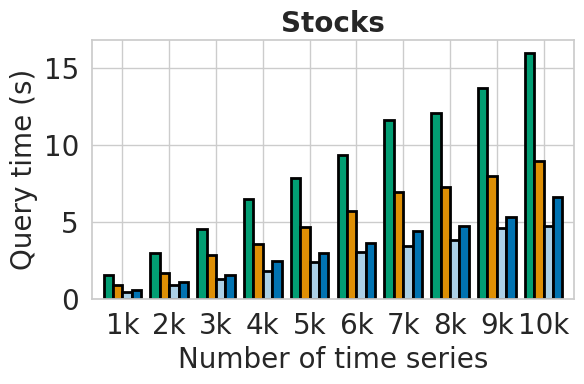

In [490]:
# Plot
plot(stats,
        outname='query_time_stocks.pdf',
        xlabel='Number of time series',
        ylabel='Query time (s)',
        dataset='Stocks',
        xticklabels=[f'{int(x/1000)}k' for x in np.sort(view.num_series.unique())]
    )

# EXP 3: Query time over m

In [410]:
view = df[
    (df.algorithm.isin(ALGOS)) &
    (df.dataset == 'stocks') &
    (df.num_channels == 5) &
    (df.num_query_channels == 5) &
    (df.series_length.isin([2048,2560,3072,3584,4096])) &
    (df.num_series == 5000) &
    (df.query_length == 1792) &
    # (df.query_length.isin([1536,1664,1792,1920,2048])) &
    True
]

view = view[
    ((~view.algorithm.str.contains("MULISSE")) | ((view.l_min == 1536) & (view.l_max == 2048)))
]

view.groupby(['algorithm', 'query_length', 'series_length']).size().unstack()

,series_length,2048.0,2560.0,3072.0,3584.0,4096.0
algorithm,query_length,,,,,
BRUTE_FORCE,1792,474,238,216,163,130
MASS,1792,131,20,20,20,20
MULISSE+BF,1792,492,223,212,132,96
MULISSE+MASS,1792,114,20,20,20,20


In [411]:
view.groupby(['algorithm', 'series_length']).num_ts_examined.median().unstack()

series_length,2048.0,2560.0,3072.0,3584.0,4096.0
algorithm,,,,,
BRUTE_FORCE,5000.0,5000.0,5000.0,5000.0,5000.0
MASS,5000.0,4045.0,5000.0,5000.0,5000.0
MULISSE+BF,2497.0,4318.0,4797.5,4895.0,4977.0
MULISSE+MASS,2565.0,3610.5,4833.0,4932.5,4801.5


In [412]:
[col for col in df.columns if 'time' in col]

['total_time_s',
 'first_layer_time_s',
 'tree_traversal_time_s',
 'io_time_s',
 'ts_examination_time_s']

In [421]:
view.groupby(['algorithm', 'series_length']).ts_examination_time_s.median().unstack()

series_length,2048.0,2560.0,3072.0,3584.0,4096.0
algorithm,,,,,
BRUTE_FORCE,7.771104,21.849217,31.407353,44.163692,50.629990
MASS,4.629267,5.899690,7.427110,8.472409,10.851725
MULISSE+BF,2.312814,13.754755,31.447661,47.137415,65.580283
MULISSE+MASS,3.402430,5.698745,7.606850,9.842741,14.574489


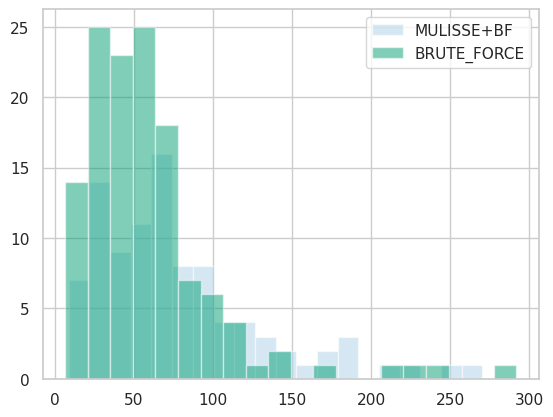

In [419]:
subview = view[
    (view.algorithm.isin(['MULISSE+BF', 'BRUTE_FORCE'])) &
    (view.series_length == 4096)
    ]

mul = subview[subview.algorithm == 'MULISSE+BF']
brute = subview[subview.algorithm == 'BRUTE_FORCE']

plt.hist(mul.ts_examination_time_s, bins=20, alpha=0.5, color=COLORS['MULISSE+BF'], label='MULISSE+BF')
plt.hist(brute.ts_examination_time_s, bins=20, alpha=0.5, color=COLORS['BRUTE_FORCE'], label='BRUTE_FORCE')
plt.legend()

plt.show()

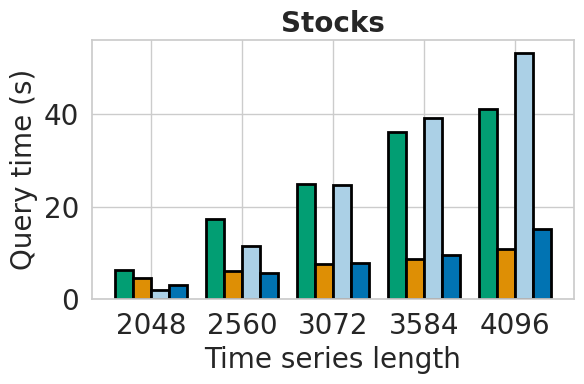

In [422]:
# Plotting
plot(view.groupby(['series_length', 'algorithm']).total_time_s.agg(iqr_mean).unstack(),
        outname='query_time_stocks_series_length.pdf',
        xlabel='Time series length',
        ylabel='Query time (s)',
        dataset='Stocks',
        xticklabels=[str(int(x)) for x in np.sort(view.series_length.unique())]
    )

# EXP 4: Query time over query length

In [253]:
view = df[
    (df.algorithm.isin(ALGOS)) &
    (df.dataset == 'stocks') &
    (df.num_channels == 5) &
    (df.num_query_channels == 5) &
    (df.series_length == 2048) &
    (df.num_series == 5000) &
    (df.query_length.isin([1536, 1664, 1792, 1920, 2048])) &
    True
]

view = view[
    ((~view.algorithm.str.contains("MULISSE")) | ((view.l_min == 1536) & (view.l_max == 2048)))
]

view.groupby(['algorithm', 'query_length']).size().unstack()

query_length,1536,1664,1792,1920,2048
algorithm,,,,,
BRUTE_FORCE,281,168,374,166,370
MASS,191,132,131,128,235
MULISSE+BF,183,185,392,187,187
MULISSE+MASS,131,113,114,110,133


In [254]:
view.groupby(['algorithm', 'query_length']).total_time_s.mean().unstack()

query_length,1536,1664,1792,1920,2048
algorithm,,,,,
BRUTE_FORCE,13.238924,9.016584,8.164831,3.886112,0.206045
MASS,4.697652,4.764289,4.735368,4.717741,4.639166
MULISSE+BF,5.808530,5.030715,2.728992,1.207082,0.085050
MULISSE+MASS,4.165894,4.008889,3.686768,3.223435,2.997865


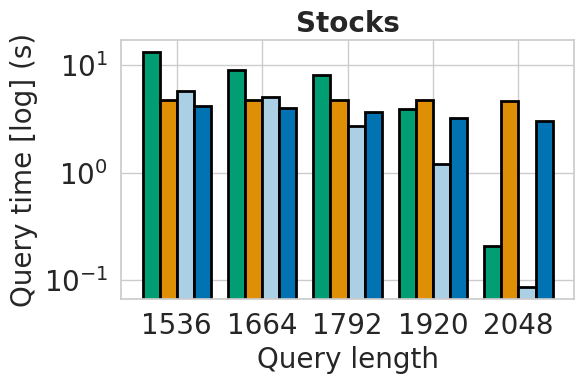

In [255]:
# Plot
plot(view.groupby(['query_length', 'algorithm']).total_time_s.mean().unstack(),
        outname='query_time_stocks_query_length.pdf',
        xlabel='Query length',
        ylabel='Query time [log] (s)',
        dataset='Stocks',
        xticklabels=[str(x) for x in np.sort(view.query_length.unique())],
        yscale=True
    )

# EXP 5: Query time over query range

In [225]:
view = df[
    (df.algorithm.isin(['MASS', 'MULISSE', 'BRUTE_FORCE'])) &
    (df.dataset == 'stocks') &
    (df.num_channels == 5) &
    (df.num_query_channels == 5) &
    (df.series_length == 2048) &
    (df.num_series == 5000) &
    (df.query_length.isin([512, 1024, 1536, 1742, 2048])) &
    True
]

view = view[
    ((~view.algorithm.str.contains("MULISSE")) | ((view.l_min >= 512) & (view.l_max == 2048)))
]

view['l_min'] = view.l_min.fillna(2048)

view.groupby(['algorithm', 'query_length', 'l_min']).size().unstack()

l_min                     512.0   1024.0  1536.0  1742.0  2048.0
algorithm   query_length                                        
BRUTE_FORCE 512              NaN     NaN     NaN     NaN    80.0
            1024             NaN     NaN     NaN     NaN   100.0
            1536             NaN     NaN     NaN     NaN   240.0
            1742             NaN     NaN     NaN     NaN   160.0
            2048             NaN     NaN     NaN     NaN   320.0
MASS        512              NaN     NaN     NaN     NaN   420.0
            1024             NaN     NaN     NaN     NaN   280.0
            1536             NaN     NaN     NaN     NaN  1301.0
            1742             NaN     NaN     NaN     NaN   560.0
            2048             NaN     NaN     NaN     NaN  1603.0
MULISSE     512             40.0     NaN     NaN     NaN     NaN
            1024            40.0    40.0     NaN     NaN     NaN
            1536            40.0    40.0  1352.0     NaN     NaN
            1742            40.0    40.0    20.0    40.0     NaN
            2048             NaN     NaN  1020.0     NaN     NaN

In [226]:
stats = view.groupby(['algorithm', 'query_length', 'l_min']).total_time_s.mean().unstack()

stats

l_min                       512.0     1024.0    1536.0    1742.0     2048.0
algorithm   query_length                                                   
BRUTE_FORCE 512                NaN       NaN       NaN       NaN  17.423792
            1024               NaN       NaN       NaN       NaN  20.354819
            1536               NaN       NaN       NaN       NaN  14.039348
            1742               NaN       NaN       NaN       NaN   8.776862
            2048               NaN       NaN       NaN       NaN   0.209191
MASS        512                NaN       NaN       NaN       NaN   4.676908
            1024               NaN       NaN       NaN       NaN   4.432263
            1536               NaN       NaN       NaN       NaN   4.692905
            1742               NaN       NaN       NaN       NaN   4.512532
            2048               NaN       NaN       NaN       NaN   4.636118
MULISSE     512           5.364280       NaN       NaN       NaN        NaN
            1024          5.221531  4.576359       NaN       NaN        NaN
            1536          4.737983  4.455975  4.134269       NaN        NaN
            1742          4.039795  4.340839  4.218198  3.893556        NaN
            2048               NaN       NaN  0.084495       NaN        NaN

In [227]:
# Get long format of the data
stats = view.groupby(['algorithm', 'query_length', 'l_min']).total_time_s.mean().unstack()

stats = stats.stack().reset_index().rename(columns={0: 'total_time_s'})

# Copy the rows for brute_force and mass
bf = stats[stats.algorithm == 'BRUTE_FORCE']
mass = stats[stats.algorithm == 'MASS']

toadd = []
for lmin in [512, 1024, 1536, 1742]:
    add = bf.copy()
    add['l_min'] = lmin

    toadd.append(add)

    add = mass.copy()
    add['l_min'] = lmin

    toadd.append(add)

stats = pd.concat([stats] + toadd)

stats.groupby(['algorithm', 'query_length', 'l_min']).total_time_s.mean().unstack()

# Plot
# plot(stats.groupby(['l_min', 'algorithm']).total_time_s.mean().unstack(),
#         outname='query_time_stocks_qrange.pdf',
#         xlabel='Minimum subsequence length',
#         ylabel='Query time (s)',
#         dataset='Stocks',
#         xticklabels=[str(x) for x in stats.l_min.unique()]
#     )

l_min                        512.0      1024.0     1536.0     1742.0  \
algorithm   query_length                                               
BRUTE_FORCE 512           17.423792  17.423792  17.423792  17.423792   
            1024          20.354819  20.354819  20.354819  20.354819   
            1536          14.039348  14.039348  14.039348  14.039348   
            1742           8.776862   8.776862   8.776862   8.776862   
            2048           0.209191   0.209191   0.209191   0.209191   
MASS        512            4.676908   4.676908   4.676908   4.676908   
            1024           4.432263   4.432263   4.432263   4.432263   
            1536           4.692905   4.692905   4.692905   4.692905   
            1742           4.512532   4.512532   4.512532   4.512532   
            2048           4.636118   4.636118   4.636118   4.636118   
MULISSE     512            5.364280        NaN        NaN        NaN   
            1024           5.221531   4.576359        NaN        NaN   
            1536           4.737983   4.455975   4.134269        NaN   
            1742           4.039795   4.340839   4.218198   3.893556   
            2048                NaN        NaN   0.084495        NaN   

l_min                        2048.0  
algorithm   query_length             
BRUTE_FORCE 512           17.423792  
            1024          20.354819  
            1536          14.039348  
            1742           8.776862  
            2048           0.209191  
MASS        512            4.676908  
            1024           4.432263  
            1536           4.692905  
            1742           4.512532  
            2048           4.636118  
MULISSE     512                 NaN  
            1024                NaN  
            1536                NaN  
            1742                NaN  
            2048                NaN

# EXP 6: Query time over channels

In [267]:
synthetic = df[
    (df.algorithm.isin(ALGOS)) &
    (df.dataset == 'big') &
    (df.num_channels == 1024) &
    (df.num_query_channels.isin([64, 128, 256, 512, 1024])) &
    (df.series_length == 2048) &
    (df.num_series == 100) &
    (df.query_length == 1792) &
    True
]

synthetic.groupby(['algorithm', 'num_query_channels']).size().unstack()

num_query_channels,64,128,256,512,1024
algorithm,,,,,
BRUTE_FORCE,181,148,132,101,90
MASS,19,20,20,20,50
MULISSE+BF,60,40,58,80,67
MULISSE+MASS,20,20,20,20,20


In [268]:
synthetic.groupby(['algorithm', 'query_length', 'num_query_channels']).total_time_s.median().unstack()

,num_query_channels,64,128,256,512,1024
algorithm,query_length,,,,,
BRUTE_FORCE,1792,7.012106,12.313185,28.450986,40.581589,50.614192
MASS,1792,1.524939,2.630234,4.721577,9.107453,18.901477
MULISSE+BF,1792,0.149686,0.248648,0.360805,0.653467,1.321732
MULISSE+MASS,1792,0.100547,0.116550,0.171672,0.232693,0.379586


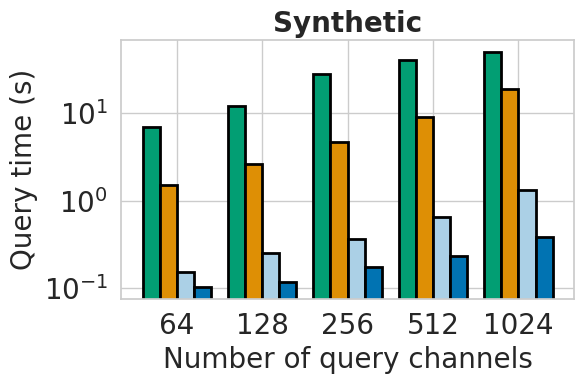

In [269]:
# Plot the query time
plot(synthetic.groupby(['num_query_channels', 'algorithm']).total_time_s.median().unstack(),
        outname='query_time_channels.pdf',
        xlabel='Number of query channels',
        ylabel='Query time (s)',
        dataset='Synthetic',
        xticklabels=[str(x) for x in synthetic.num_query_channels.unique()],
        yscale=True
    )

# EXP 7: Query time over dataset

In [391]:
stocks = df[
    (df.algorithm.isin(ALGOS)) &
    (df.dataset == 'stocks') &
    (df.num_channels == 5) &
    (df.num_query_channels == 5) &
    (df.series_length == 2048) &
    (df.num_series == 5000) &
    (df.query_length == 1792) &
    True
]

weather = df[
    (df.algorithm.isin(ALGOS)) &
    (df.dataset == 'weather') &
    (df.num_channels == 4) &
    (df.num_query_channels == 4) &
    (df.series_length == 2048) &
    (df.num_series == 5000) &
    (df.query_length == 1792) &
    True
]

synthetic = df[
    (df.algorithm.isin(ALGOS)) &
    (df.dataset == 'big') &
    (df.num_channels == 1024) &
    (df.num_query_channels == 1024) &
    (df.series_length == 2048) &
    (df.num_series == 100) &
    (df.query_length == 1792) &
    True
]

view = pd.concat([stocks, weather, synthetic])

view = view[
    ((~view.algorithm.str.contains("MULISSE")) | ((view.l_min == 1536) & (view.l_max == 2048)))
]

view.groupby(['algorithm', 'dataset']).size().unstack()

dataset,big,stocks,weather
algorithm,,,
BRUTE_FORCE,92,374,27
MASS,50,131,20
MULISSE+BF,67,392,31
MULISSE+MASS,20,114,20


In [392]:
view.groupby(['algorithm', 'dataset']).total_time_s.median().unstack()

dataset,big,stocks,weather
algorithm,,,
BRUTE_FORCE,50.946538,7.886283,13.461363
MASS,18.901477,4.747287,3.762971
MULISSE+BF,1.321732,2.301992,5.234467
MULISSE+MASS,0.379586,3.551901,3.436049


In [394]:
view.groupby(['algorithm', 'dataset']).num_ts_examined.mean().unstack()

dataset,big,stocks,weather
algorithm,,,
BRUTE_FORCE,100.0,5000.000000,5000.000000
MASS,100.0,5000.000000,5000.000000
MULISSE+BF,1.0,2567.005102,4642.129032
MULISSE+MASS,1.0,2864.587719,4639.450000


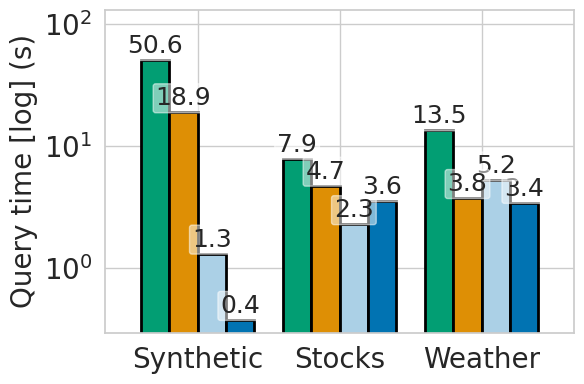

In [276]:
# Plot
plot(view.groupby(['dataset', 'algorithm']).total_time_s.median().unstack(),
        outname='query_time_datasets.pdf',
        xlabel=None,
        ylabel='Query time [log] (s)',
        dataset=None,
        xticklabels=['Synthetic', 'Stocks', 'Weather'],
        yscale=True,
        annot=True
    )

# Legend

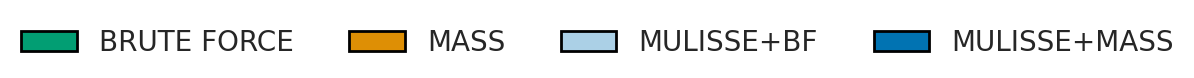

In [60]:
# Create a pointplot
fig,ax = plt.subplots(1,1, figsize=(7,.5))

for i, alg in enumerate(['BRUTE_FORCE', 'MASS', 'MULISSE+BF', 'MULISSE+MASS']):
    c = COLORS[alg]
    ax.bar([i],[1000], color=c, label=alg.replace("_", " "), edgecolor='black', linewidth=2, width=0.8)

ax.legend(loc='upper center', ncol=7, frameon=False, fontsize=FONTSIZE, bbox_to_anchor=(0.5, 1), bbox_transform=fig.transFigure)

# ax.set_xlim(-1,0)
ax.set_ylim(-10,-5)

# Remove the borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)

ax.set_xticks([])
ax.set_yticks([])
ax.set_xlabel("")
ax.set_ylabel("")

fig.savefig(os.path.join(FIGDIR,"legend_bar.pdf"), dpi=300, bbox_inches="tight")

# Compare with ms-index

In [236]:
view = df[
    (df.algorithm.isna() == False) &
    (df.dataset == 'stocks') &
    (df.num_channels == df.num_query_channels) &
    (df.num_series == 1000) &
    (df.series_length == 2000) &
    (df.query_length == 730) &
    ((~df.algorithm.str.contains("MULISSE")) | (df.l_min == 730)) &
    True
]

view.groupby(['algorithm']).size()

TypeError: bad operand type for unary ~: 'float'

In [15]:
view.groupby(['algorithm']).total_time_s.mean()

algorithm
MASS       0.753089
MULISSE    0.753439
Name: total_time_s, dtype: float64